# Fraud Detection - Notebook 4: XGBoost + LightGBM Ensemble

1. **Load** XGBoost scores (notebook 3) and graph + tabular features (notebook 2)
2. **LightGBM** — same features as XGBoost, different boosting algorithm for diversity
3. **Meta-learner ensemble** — logistic regression on XGBoost + LightGBM scores
4. **SHAP interpretability** — global feature importance and per-transaction explanations
5. **Precision@K**, cost-threshold optimisation, evaluation dashboard

### Why LightGBM instead of Isolation Forest
IF dropped to AUROC 0.614 after removing `g_fraud_density` (which was leaking test labels). Without that feature IF has no label signal and contributes nothing to the ensemble. LightGBM uses the same supervised signal as XGBoost but via leaf-wise tree growth and histogram binning — different inductive bias gives genuine score diversity.

In [22]:
import sys, json, numpy as np, pandas as pd, warnings, subprocess
from pathlib import Path
warnings.filterwarnings('ignore')

IEEE_DIR  = Path('/kaggle/input/competitions/ieee-fraud-detection')
SRC_DIR   = Path('/kaggle/input/datasets/youssefmousaaid/fraud-detection-src')
WORK_DIR  = Path('/kaggle/working')
PROC_DIR  = WORK_DIR / 'processed'
MDL_DIR   = WORK_DIR / 'models'
OUT_DIR   = WORK_DIR / 'outputs'

for d in [PROC_DIR, MDL_DIR, OUT_DIR,
          OUT_DIR/'eda', OUT_DIR/'graph', OUT_DIR/'model',
          OUT_DIR/'isolation_forest', OUT_DIR/'ensemble',
          OUT_DIR/'drift', OUT_DIR/'pipeline', WORK_DIR/'mlruns']:
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(SRC_DIR))

# Install shap if not present
subprocess.run([sys.executable, '-m', 'pip', 'install', 'shap', '-q'], check=True)
print('Paths ready')

Paths ready


In [23]:
import pickle, gc, shap
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, confusion_matrix, classification_report)
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
plt.rcParams.update({'figure.facecolor':'#0F1117','axes.facecolor':'#1A1D27',
    'axes.edgecolor':'#2E3347','text.color':'#E0E0E0','axes.labelcolor':'#E0E0E0',
    'xtick.color':'#9AA0B0','ytick.color':'#9AA0B0','grid.color':'#2E3347',
    'grid.linestyle':'--','font.family':'monospace'})
PAL = {'xgb':'#4A90D9','lgb':'#A259FF','ensemble':'#F5A623','fraud':'#E84545','normal':'#4CAF50'}

print(f'LightGBM : {lgb.__version__}')
print(f'SHAP     : {shap.__version__}')

LightGBM : 4.6.0
SHAP     : 0.50.0


In [24]:
# ── Load all arrays ─────────────────────────────────────────────────────
with open(PROC_DIR/'graph_meta.json') as f:
    GRAPH_FEATURES = json.load(f)['graph_features']
with open(PROC_DIR/'sequence_meta.json') as f:
    meta = json.load(f)
N_TAB   = meta['n_features']
SEQ_LEN = meta['seq_len']
MID     = SEQ_LEN // 2
FEATURE_NAMES = meta['features'] + GRAPH_FEATURES

# ── Test set ────────────────────────────────────────────────────────────
xgb_scores  = np.load(PROC_DIR/'test_scores.npy')
score_txids = np.load(PROC_DIR/'test_score_txids.npy')
G_test      = np.load(PROC_DIR/'graph_features_test.npy')
g_tx_test   = np.load(PROC_DIR/'graph_tx_ids_test.npy')
y_test      = np.load(PROC_DIR/'y_graph_test.npy')
X_test_tab  = np.load(PROC_DIR/'X_test_tab.npy')
tx_ids_test = np.load(PROC_DIR/'tx_ids_test_tab.npy')

assert np.array_equal(score_txids, g_tx_test), \
    'XGBoost score TxIDs do not match graph test TxIDs — rerun notebook 3'
print(f'Test aligned: {len(xgb_scores):,} rows | fraud={y_test.sum()} ({y_test.mean()*100:.2f}%)')

# Join tabular features to graph test rows
tab_lookup = {int(tid): i for i, tid in enumerate(tx_ids_test)}
X_tab_test = np.zeros((len(G_test), N_TAB), dtype=np.float32)
for i, tid in enumerate(g_tx_test):
    idx = tab_lookup.get(int(tid))
    if idx is not None:
        X_tab_test[i] = X_test_tab[idx]
tab_cov = sum(1 for tid in g_tx_test if int(tid) in tab_lookup) / len(g_tx_test)
print(f'Tabular coverage (test): {tab_cov*100:.1f}%')

X_test_full = np.hstack([X_tab_test, G_test])
del X_tab_test, X_test_tab; gc.collect()

# ── Training set ─────────────────────────────────────────────────────────
G_train         = np.load(PROC_DIR/'graph_features_train.npy')
g_tx_train      = np.load(PROC_DIR/'graph_tx_ids_train.npy')
y_train         = np.load(PROC_DIR/'y_graph_train.npy')
X_train_tab_all = np.load(PROC_DIR/'X_train_tab_all.npy')
tx_ids_train    = np.load(PROC_DIR/'tx_ids_train_all.npy')

tab_train_lookup = {int(tid): i for i, tid in enumerate(tx_ids_train)}
X_tab_train = np.zeros((len(G_train), N_TAB), dtype=np.float32)
for i, tid in enumerate(g_tx_train):
    idx = tab_train_lookup.get(int(tid))
    if idx is not None:
        X_tab_train[i] = X_train_tab_all[idx]
tab_cov_tr = sum(1 for tid in g_tx_train if int(tid) in tab_train_lookup) / len(g_tx_train)
print(f'Tabular coverage (train): {tab_cov_tr*100:.1f}%')

X_train_full = np.hstack([X_tab_train, G_train])
del X_tab_train, X_train_tab_all, G_train; gc.collect()

print(f'X_train: {X_train_full.shape} | fraud={y_train.sum()} ({y_train.mean()*100:.2f}%)')
print(f'X_test : {X_test_full.shape}')

Test aligned: 118,108 rows | fraud=4133 (3.50%)
Tabular coverage (test): 11.4%
Tabular coverage (train): 11.5%
X_train: (472432, 39) | fraud=16530 (3.50%)
X_test : (118108, 39)


In [25]:
# ── LightGBM ────────────────────────────────────────────────────────────
# Leaf-wise growth (vs XGBoost level-wise) and histogram binning give
# genuinely different decision boundaries on the same features, producing
# score diversity that lifts the ensemble.
n_normal         = int((y_train == 0).sum())
n_fraud          = int((y_train == 1).sum())
scale_pos_weight = n_normal / max(n_fraud, 1)
print(f'scale_pos_weight: {scale_pos_weight:.1f}  (normal={n_normal:,}  fraud={n_fraud:,})')

lgb_params = {
    'objective'        : 'binary',
    'metric'           : 'average_precision',
    'boosting_type'    : 'gbdt',
    'n_estimators'     : 2000,
    'learning_rate'    : 0.03,
    'num_leaves'       : 63,       # richer than XGBoost max_depth=6 (2^6-1=63)
    'min_child_samples': 20,       # equivalent to min_child_weight
    'subsample'        : 0.8,
    'subsample_freq'   : 1,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'scale_pos_weight' : scale_pos_weight,
    'random_state'     : 42,
    'device'           : 'cpu',    # GPU acceleration
    'verbose'          : -1,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_lgb    = np.zeros(len(X_train_full))
cv_aurocs  = []
best_iters = []
best_lgb_models = []

print('Cross-validated LightGBM (5 folds)...')
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_full, y_train)):
    import time; t0 = time.time()
    X_tr, X_val = X_train_full[tr_idx], X_train_full[val_idx]
    y_tr, y_val = y_train[tr_idx],      y_train[val_idx]

    clf = lgb.LGBMClassifier(**lgb_params, n_jobs=-1)
    clf.fit(
        X_tr, y_tr,
        eval_set          = [(X_val, y_val)],
        callbacks         = [lgb.early_stopping(100, verbose=False),
                             lgb.log_evaluation(period=-1)],
    )
    val_proba = clf.predict_proba(X_val)[:, 1]
    oof_lgb[val_idx] = val_proba
    fold_auroc = roc_auc_score(y_val, val_proba)
    cv_aurocs.append(fold_auroc)
    best_iters.append(clf.best_iteration_)
    best_lgb_models.append(clf)
    print(f'  Fold {fold+1}: AUROC={fold_auroc:.4f} | best_iter={clf.best_iteration_} | {time.time()-t0:.1f}s')

print(f'\nCV mean  : {np.mean(cv_aurocs):.4f} +/- {np.std(cv_aurocs):.4f}')
print(f'OOF AUROC: {roc_auc_score(y_train, oof_lgb):.4f}')

scale_pos_weight: 27.6  (normal=455,902  fraud=16,530)
Cross-validated LightGBM (5 folds)...
  Fold 1: AUROC=0.7992 | best_iter=2000 | 66.5s
  Fold 2: AUROC=0.7950 | best_iter=1970 | 66.5s
  Fold 3: AUROC=0.8009 | best_iter=1993 | 66.6s
  Fold 4: AUROC=0.7917 | best_iter=1858 | 64.8s
  Fold 5: AUROC=0.7974 | best_iter=1769 | 62.1s

CV mean  : 0.7969 +/- 0.0032
OOF AUROC: 0.7967


In [26]:
# Final LightGBM model on all training data
best_n_lgb = int(np.median(best_iters))
print(f'Training final LightGBM | n_estimators={best_n_lgb}...')

final_lgb_params = {**lgb_params, 'n_estimators': best_n_lgb}
final_lgb = lgb.LGBMClassifier(**final_lgb_params, n_jobs=-1)
final_lgb.fit(X_train_full, y_train)

lgb_scores = final_lgb.predict_proba(X_test_full)[:, 1]
auroc_lgb  = roc_auc_score(y_test, lgb_scores)
auprc_lgb  = average_precision_score(y_test, lgb_scores)
auroc_xgb  = roc_auc_score(y_test, xgb_scores)
auprc_xgb  = average_precision_score(y_test, xgb_scores)

print(f'XGBoost  : AUROC={auroc_xgb:.4f}  AUPRC={auprc_xgb:.4f}')
print(f'LightGBM : AUROC={auroc_lgb:.4f}  AUPRC={auprc_lgb:.4f}')

with open(MDL_DIR/'lgb_model.pkl', 'wb') as f: pickle.dump(final_lgb, f)
np.save(PROC_DIR/'lgb_scores_test.npy', lgb_scores)

Training final LightGBM | n_estimators=1970...
XGBoost  : AUROC=0.7990  AUPRC=0.1738
LightGBM : AUROC=0.8029  AUPRC=0.1923


In [27]:
# ── Meta-learner ensemble ───────────────────────────────────────────────
def safe_norm(s):
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo + 1e-9)

xn  = safe_norm(xgb_scores)
ln  = safe_norm(lgb_scores)
y   = y_test

X_meta = np.column_stack([xn, ln, xn*ln, np.abs(xn-ln), np.maximum(xn,ln)])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_aurocs_ens = []
for fold, (tr, val) in enumerate(skf.split(X_meta, y)):
    meta = LogisticRegression(C=0.1, max_iter=1000, random_state=42, class_weight='balanced')
    meta.fit(X_meta[tr], y[tr])
    proba = meta.predict_proba(X_meta[val])[:,1]
    cv_aurocs_ens.append(roc_auc_score(y[val], proba))
    print(f'  Fold {fold+1}: AUROC={cv_aurocs_ens[-1]:.4f}')
print(f'  CV mean: {np.mean(cv_aurocs_ens):.4f} +/- {np.std(cv_aurocs_ens):.4f}')

meta_final = LogisticRegression(C=0.1, max_iter=1000, random_state=42, class_weight='balanced')
meta_final.fit(X_meta, y)
ens_proba = meta_final.predict_proba(X_meta)[:,1]
auroc_ens = roc_auc_score(y, ens_proba)
auprc_ens = average_precision_score(y, ens_proba)
print(f'\nXGBoost: {auroc_xgb:.4f}  LightGBM: {auroc_lgb:.4f}  Ensemble: {auroc_ens:.4f}')

  Fold 1: AUROC=0.8054
  Fold 2: AUROC=0.8118
  Fold 3: AUROC=0.8008
  Fold 4: AUROC=0.8057
  Fold 5: AUROC=0.8074
  CV mean: 0.8062 +/- 0.0035

XGBoost: 0.7990  LightGBM: 0.8029  Ensemble: 0.8063


In [28]:
# ── Precision@K and cost analysis ──────────────────────────────────────
COST_FN, COST_FP = 150.0, 5.0

prec, rec, pr_thr = precision_recall_curve(y, ens_proba)
f1s    = 2*prec*rec / (prec+rec+1e-9)
thr_f1 = pr_thr[np.argmax(f1s[:-1])]

thr_range = np.linspace(0.01, 0.99, 200)
costs = []
for thr in thr_range:
    yp = (ens_proba >= thr).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y, yp, labels=[0,1]).ravel()
    costs.append(fn_*COST_FN + fp_*COST_FP)
best_cost_thr = thr_range[np.argmin(costs)]

y_pred = (ens_proba >= thr_f1).astype(int)
cm = confusion_matrix(y, y_pred)
tn_, fp_, fn_, tp_ = cm.ravel()
print(classification_report(y, y_pred, target_names=['Normal','Fraud']))
print(f'Cost at F1 threshold ({thr_f1:.3f}) : ${fn_*COST_FN + fp_*COST_FP:,.0f}')
print(f'Min cost at optimal  ({best_cost_thr:.3f}) : ${min(costs):,.0f}')

sorted_idx = np.argsort(ens_proba)[::-1]
print('\nPrecision@K:')
for k in [10, 25, 50, 100, 200, 500]:
    p = y[sorted_idx[:k]].sum() / k
    print(f'  P@{k:>4}: {p:.3f}  {"#"*int(p*20)}')

              precision    recall  f1-score   support

      Normal       0.98      0.96      0.97    113975
       Fraud       0.22      0.33      0.27      4133

    accuracy                           0.94    118108
   macro avg       0.60      0.65      0.62    118108
weighted avg       0.95      0.94      0.94    118108

Cost at F1 threshold (0.823) : $437,490
Min cost at optimal  (0.478) : $322,655

Precision@K:
  P@  10: 0.800  ################
  P@  25: 0.760  ###############
  P@  50: 0.680  #############
  P@ 100: 0.650  #############
  P@ 200: 0.590  ###########
  P@ 500: 0.508  ##########


In [29]:
# ── SHAP interpretability ───────────────────────────────────────────────
# Use the final LightGBM model — TreeExplainer is exact for tree models
# and runs in O(TLD) time (T=trees, L=leaves, D=depth).
# We explain 2000 test samples for speed; full test set would work too.

print('Computing SHAP values (LightGBM TreeExplainer)...')
explainer   = shap.TreeExplainer(final_lgb)
N_SHAP      = min(2000, len(X_test_full))
# Stratified sample: equal fraud/normal representation
fraud_idx  = np.where(y_test == 1)[0]
normal_idx = np.where(y_test == 0)[0]
n_fraud_s  = min(len(fraud_idx),  N_SHAP // 2)
n_normal_s = min(len(normal_idx), N_SHAP - n_fraud_s)
shap_idx   = np.concatenate([
    np.random.choice(fraud_idx,  n_fraud_s,  replace=False),
    np.random.choice(normal_idx, n_normal_s, replace=False),
])
X_shap      = X_test_full[shap_idx]
y_shap      = y_test[shap_idx]
shap_values = explainer.shap_values(X_shap)

# LightGBM binary: shap_values may be list [neg_class, pos_class]
if isinstance(shap_values, list):
    shap_values = shap_values[1]   # positive class (fraud)

print(f'SHAP values shape: {shap_values.shape}')
print(f'Sample: {n_fraud_s} fraud + {n_normal_s} normal')

Computing SHAP values (LightGBM TreeExplainer)...
SHAP values shape: (2000, 39)
Sample: 1000 fraud + 1000 normal


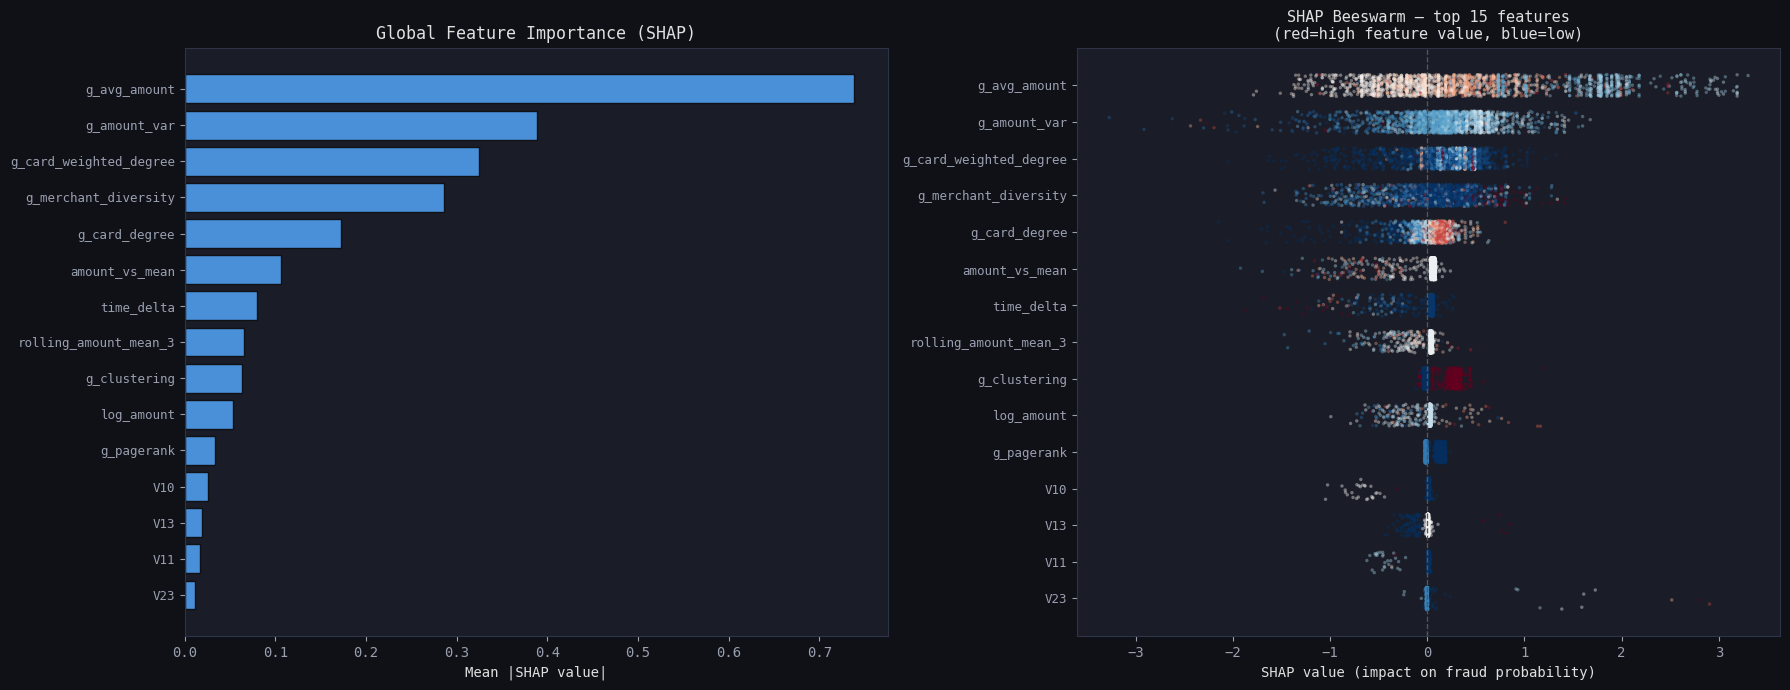

Saved: shap_importance.png


In [30]:
# ── SHAP plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0F1117')

# ── Panel 1: Mean absolute SHAP (global importance bar chart) ───────────
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_order = np.argsort(mean_abs_shap)[::-1]
top_n = 15
top_idx   = importance_order[:top_n]
top_names = [FEATURE_NAMES[i] for i in top_idx]
top_vals  = mean_abs_shap[top_idx]

axes[0].barh(range(top_n), top_vals[::-1], color=PAL['xgb'], edgecolor='#0F1117')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_names[::-1], fontsize=9)
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('Global Feature Importance (SHAP)', color='#E0E0E0', fontsize=12)
axes[0].tick_params(colors='#9AA0B0')

# ── Panel 2: SHAP beeswarm — top 15 features, coloured by feature value ─
top15_shap  = shap_values[:, top_idx]
top15_feats = X_shap[:, top_idx]

# Normalise each feature to [0,1] for colour mapping
def norm_col(arr):
    mn, mx = arr.min(0), arr.max(0)
    return (arr - mn) / (mx - mn + 1e-9)

feat_norm = norm_col(top15_feats)

for rank in range(top_n - 1, -1, -1):   # plot bottom feature first so top is visible
    y_pos   = np.full(len(top15_shap), top_n - 1 - rank)
    # Add vertical jitter to separate overlapping points
    jitter  = np.random.uniform(-0.3, 0.3, len(top15_shap))
    colors  = plt.cm.RdBu_r(feat_norm[:, rank])
    axes[1].scatter(top15_shap[:, rank], y_pos + jitter,
                    c=colors, alpha=0.4, s=6, linewidths=0)

axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(top_names[::-1], fontsize=9)
axes[1].axvline(0, color='#555', lw=1, ls='--')
axes[1].set_xlabel('SHAP value (impact on fraud probability)')
axes[1].set_title('SHAP Beeswarm — top 15 features\n(red=high feature value, blue=low)',
                  color='#E0E0E0', fontsize=11)
axes[1].tick_params(colors='#9AA0B0')

plt.tight_layout()
plt.savefig(OUT_DIR/'ensemble/shap_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1117')
plt.show()
print('Saved: shap_importance.png')

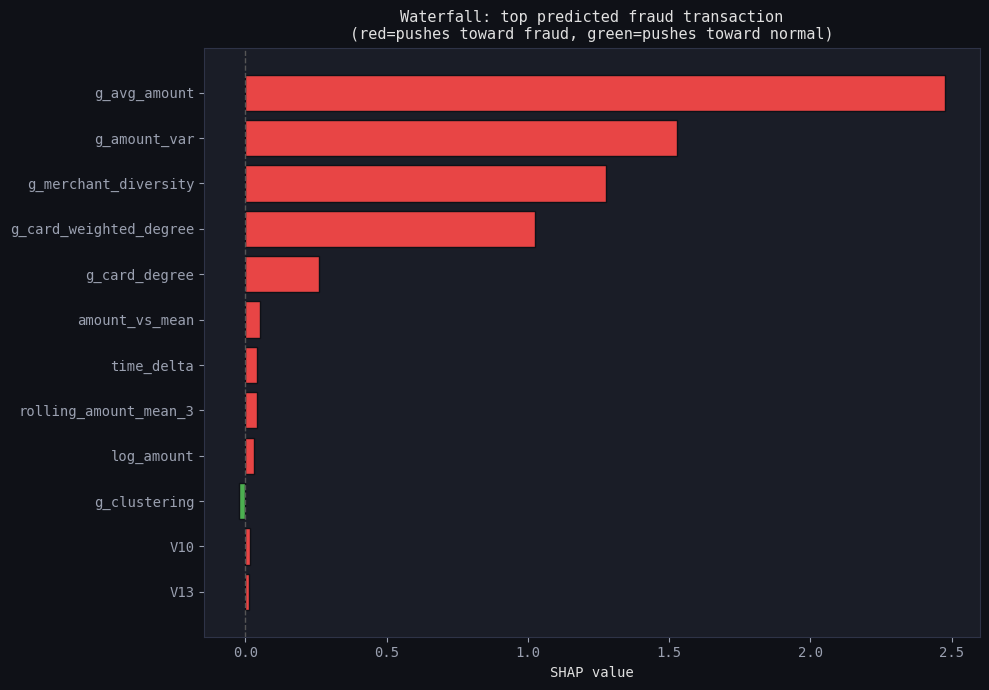

Saved: shap_waterfall.png


In [31]:
# ── SHAP waterfall: highest-scoring fraud transaction ───────────────────
# Show which features drove the model's decision for the most confidently
# flagged fraud transaction in the SHAP sample.
fraud_in_sample = np.where(y_shap == 1)[0]
if len(fraud_in_sample) > 0:
    top_fraud_local = fraud_in_sample[np.argmax(shap_values[fraud_in_sample].sum(axis=1))]

    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor('#0F1117')
    ax.set_facecolor('#1A1D27')

    sv   = shap_values[top_fraud_local]
    order = np.argsort(np.abs(sv))[::-1][:12]   # top 12 by magnitude
    names = [FEATURE_NAMES[i] for i in order]
    vals  = sv[order]
    colors = [PAL['fraud'] if v > 0 else PAL['normal'] for v in vals]

    ax.barh(range(len(vals)), vals[::-1], color=colors[::-1], edgecolor='#0F1117')
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(names[::-1], fontsize=10)
    ax.axvline(0, color='#555', lw=1, ls='--')
    ax.set_xlabel('SHAP value')
    ax.set_title('Waterfall: top predicted fraud transaction\n(red=pushes toward fraud, green=pushes toward normal)',
                 color='#E0E0E0', fontsize=11)
    ax.tick_params(colors='#9AA0B0')
    plt.tight_layout()
    plt.savefig(OUT_DIR/'ensemble/shap_waterfall.png', dpi=150,
                bbox_inches='tight', facecolor='#0F1117')
    plt.show()
    print('Saved: shap_waterfall.png')
else:
    print('No fraud transactions in SHAP sample — increase N_SHAP')

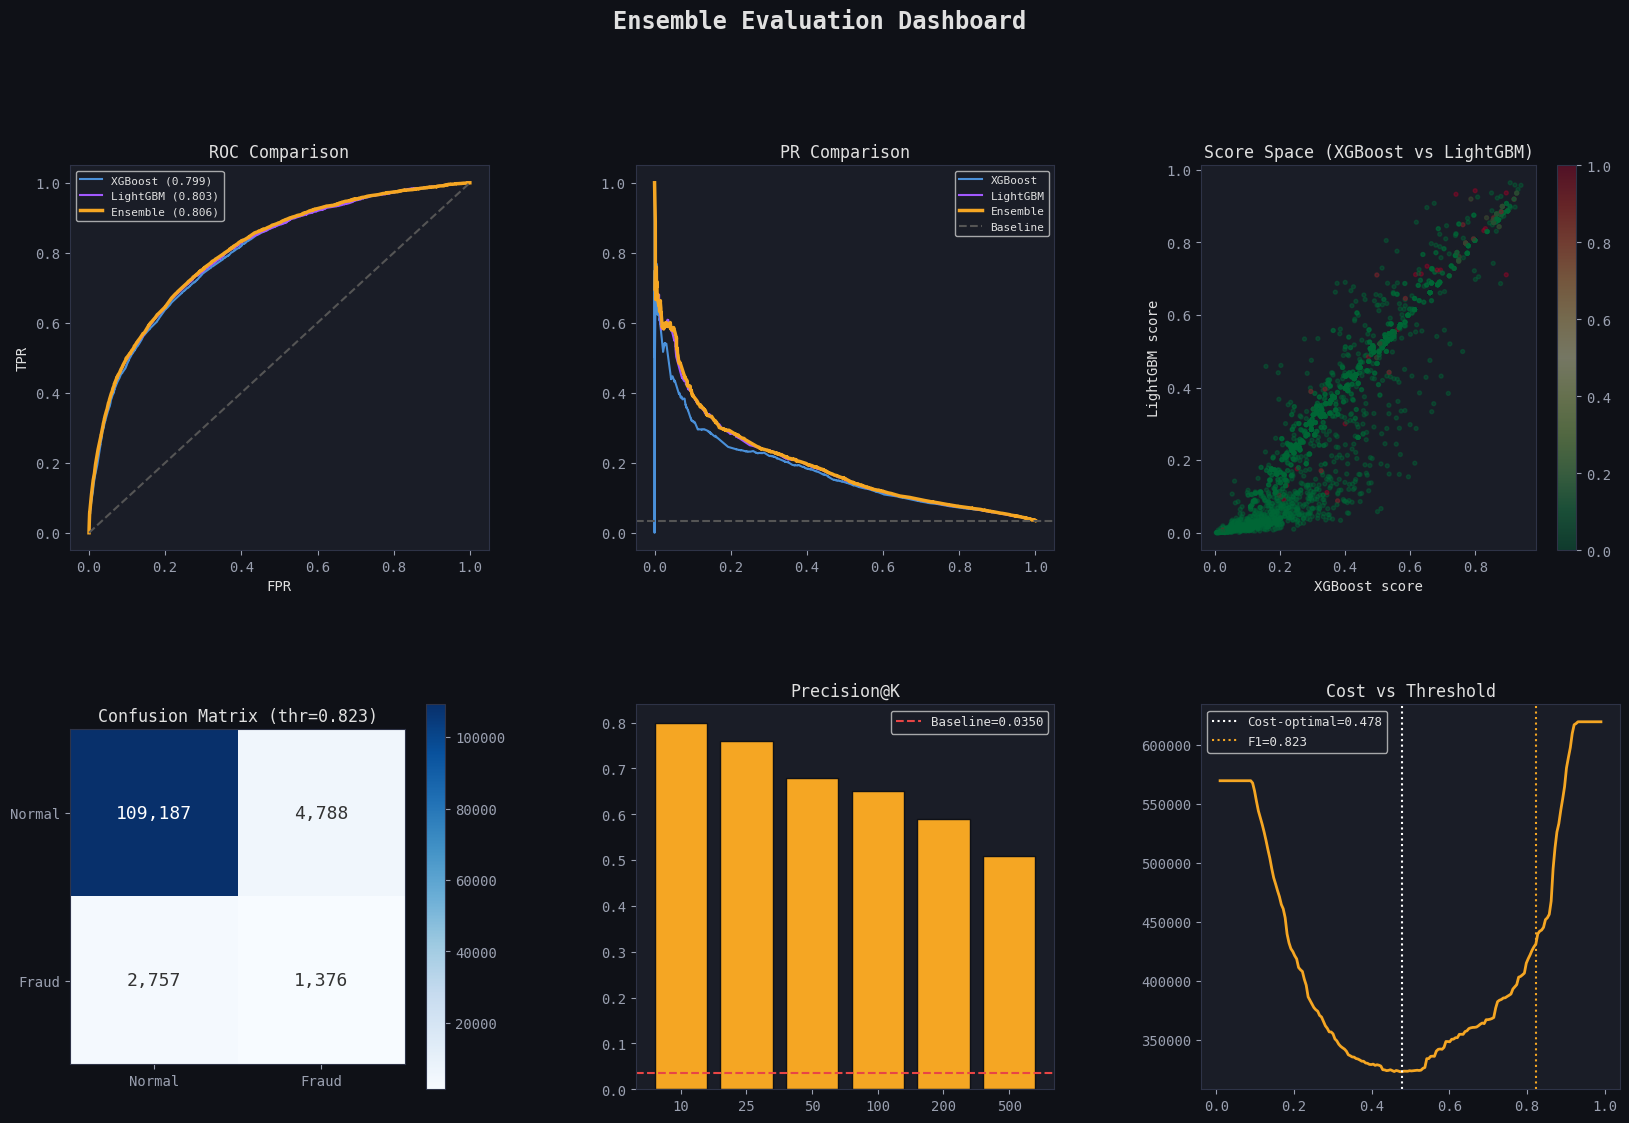

In [32]:
# ── Evaluation dashboard ────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.patch.set_facecolor('#0F1117')

# ROC
ax1 = fig.add_subplot(gs[0,0])
for sc, lb, col in [
    (xn,  f'XGBoost ({auroc_xgb:.3f})',  PAL['xgb']),
    (ln,  f'LightGBM ({auroc_lgb:.3f})', PAL['lgb']),
    (ens_proba, f'Ensemble ({auroc_ens:.3f})', PAL['ensemble']),
]:
    fpr_, tpr_, _ = roc_curve(y, sc)
    ax1.plot(fpr_, tpr_, color=col, lw=2.5 if 'Ens' in lb else 1.5, label=lb)
ax1.plot([0,1],[0,1],'--',color='#555')
ax1.set_title('ROC Comparison', color='#E0E0E0')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR'); ax1.legend(fontsize=8)

# PR
ax2 = fig.add_subplot(gs[0,1])
for sc, lb, col in [
    (xn,  'XGBoost',  PAL['xgb']),
    (ln,  'LightGBM', PAL['lgb']),
    (ens_proba, 'Ensemble', PAL['ensemble']),
]:
    p_, r_, _ = precision_recall_curve(y, sc)
    ax2.plot(r_, p_, color=col, lw=2.5 if lb=='Ensemble' else 1.5, label=lb)
ax2.axhline(y.mean(), color='#555', ls='--', label='Baseline')
ax2.set_title('PR Comparison', color='#E0E0E0'); ax2.legend(fontsize=8)

# Score space
ax3 = fig.add_subplot(gs[0,2])
idx_s  = np.random.choice(len(y), min(3000, len(y)), replace=False)
sc_plt = ax3.scatter(xn[idx_s], ln[idx_s], c=y[idx_s],
                     cmap='RdYlGn_r', alpha=0.4, s=8)
ax3.set_title('Score Space (XGBoost vs LightGBM)', color='#E0E0E0')
ax3.set_xlabel('XGBoost score'); ax3.set_ylabel('LightGBM score')
plt.colorbar(sc_plt, ax=ax3)

# Confusion matrix
ax4 = fig.add_subplot(gs[1,0])
im = ax4.imshow(cm, cmap='Blues')
ax4.set_xticks([0,1]); ax4.set_yticks([0,1])
ax4.set_xticklabels(['Normal','Fraud']); ax4.set_yticklabels(['Normal','Fraud'])
ax4.set_title(f'Confusion Matrix (thr={thr_f1:.3f})', color='#E0E0E0')
for i in range(2):
    for j in range(2):
        ax4.text(j, i, f'{cm[i,j]:,}', ha='center', va='center', fontsize=13,
                 color='white' if cm[i,j] > cm.max()/2 else '#333')
plt.colorbar(im, ax=ax4)

# Precision@K
ax5 = fig.add_subplot(gs[1,1])
ks_ = [10, 25, 50, 100, 200, 500]
pk_ = [y[sorted_idx[:k]].sum()/k for k in ks_]
ax5.bar([str(k) for k in ks_], pk_, color=PAL['ensemble'], edgecolor='#0F1117')
ax5.axhline(y.mean(), color=PAL['fraud'], ls='--', lw=1.5,
            label=f'Baseline={y.mean():.4f}')
ax5.set_title('Precision@K', color='#E0E0E0'); ax5.legend(fontsize=9)

# Cost vs threshold
ax6 = fig.add_subplot(gs[1,2])
ax6.plot(thr_range, costs, color=PAL['ensemble'], lw=2)
ax6.axvline(best_cost_thr, color='white',         lw=1.5, ls=':',
            label=f'Cost-optimal={best_cost_thr:.3f}')
ax6.axvline(thr_f1,        color=PAL['ensemble'], lw=1.5, ls=':',
            label=f'F1={thr_f1:.3f}')
ax6.set_title('Cost vs Threshold', color='#E0E0E0'); ax6.legend(fontsize=9)

fig.suptitle('Ensemble Evaluation Dashboard', fontsize=17,
             fontweight='bold', color='#E0E0E0', y=1.01)
plt.savefig(OUT_DIR/'ensemble/01_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1117')
plt.show()

In [33]:
# ── Save ────────────────────────────────────────────────────────────────
ss_xgb = MinMaxScaler().fit(xgb_scores.reshape(-1,1))
ss_lgb = MinMaxScaler().fit(lgb_scores.reshape(-1,1))
with open(MDL_DIR/'ensemble.pkl','wb') as f:
    pickle.dump({'meta_learner'    : meta_final,
                 'score_scaler_xgb': ss_xgb,
                 'score_scaler_lgb': ss_lgb,
                 'lgb_model'       : final_lgb}, f)

np.save(PROC_DIR/'shap_values.npy',       shap_values)
np.save(PROC_DIR/'shap_sample_idx.npy',   shap_idx)
np.save(PROC_DIR/'shap_feature_names.npy',
        np.array(FEATURE_NAMES, dtype=object))

results = {
    'xgb_auroc'      : round(float(auroc_xgb), 4),
    'lgb_auroc'      : round(float(auroc_lgb), 4),
    'ensemble_auroc' : round(float(auroc_ens), 4),
    'ensemble_auprc' : round(float(auprc_ens), 4),
    'threshold_f1'   : round(float(thr_f1),    6),
    'threshold_cost' : round(float(best_cost_thr), 6),
    'precision_at_k' : {str(k): round(float(y[sorted_idx[:k]].sum()/k), 4)
                        for k in [10, 25, 50, 100, 200, 500]},
    'top_shap_features': [
        {'feature': FEATURE_NAMES[i], 'mean_abs_shap': round(float(mean_abs_shap[i]), 6)}
        for i in importance_order[:10]
    ],
}
with open(MDL_DIR/'ensemble_results.json','w') as f:
    json.dump(results, f, indent=2)

print(f'XGBoost : {auroc_xgb:.4f}')
print(f'LightGBM: {auroc_lgb:.4f}')
print(f'Ensemble: {auroc_ens:.4f}')
print(json.dumps(results, indent=2))
print('\nNext: 05_drift_and_retraining.ipynb')

XGBoost : 0.7990
LightGBM: 0.8029
Ensemble: 0.8063
{
  "xgb_auroc": 0.799,
  "lgb_auroc": 0.8029,
  "ensemble_auroc": 0.8063,
  "ensemble_auprc": 0.1951,
  "threshold_f1": 0.822945,
  "threshold_cost": 0.477839,
  "precision_at_k": {
    "10": 0.8,
    "25": 0.76,
    "50": 0.68,
    "100": 0.65,
    "200": 0.59,
    "500": 0.508
  },
  "top_shap_features": [
    {
      "feature": "g_avg_amount",
      "mean_abs_shap": 0.73814
    },
    {
      "feature": "g_amount_var",
      "mean_abs_shap": 0.388875
    },
    {
      "feature": "g_card_weighted_degree",
      "mean_abs_shap": 0.325033
    },
    {
      "feature": "g_merchant_diversity",
      "mean_abs_shap": 0.285862
    },
    {
      "feature": "g_card_degree",
      "mean_abs_shap": 0.171802
    },
    {
      "feature": "amount_vs_mean",
      "mean_abs_shap": 0.106541
    },
    {
      "feature": "time_delta",
      "mean_abs_shap": 0.079954
    },
    {
      "feature": "rolling_amount_mean_3",
      "mean_abs_shap": 0.0